In [1]:
import einops
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
nsa_l = 32  # compression block size
nsa_d = 16  # sliding stride
nsa_L = 64  # selected block size
nsa_n = 16  # selected block count
nsa_w = 512  # window size

assert nsa_d < nsa_l, "NSA authors require d < l to avoid information fragmentation"
assert nsa_l <= nsa_L, "NSA authors require l <= l'"
assert nsa_l % nsa_d == 0, "NSA authors require d | l"
assert nsa_L % nsa_d == 0, "NSA authors require d | l'"

# Table 1

In [3]:
context_lengths = [8192, 16384, 32768, 65536]
num_draft_tokens = 3  # num_verified_tokens = num_draft_tokens + 1

full_attention = {}
nsa_worst = {}
nsa_best = {}
nsa_best_over_worst = {}

for L in context_lengths:
    full = L
    full_attention[L] = f"{full}"

    compression = L // nsa_d
    selection = min(nsa_L * nsa_n * (num_draft_tokens + 1), L)
    window = min(nsa_w, L)
    total_worst = compression + selection + window
    nsa_worst[L] = f"{total_worst}"

    selection = min(nsa_L * nsa_n, L)
    total_best = compression + selection + window
    nsa_best[L] = f"{total_best}"

    nsa_best_over_worst[L] = f"**{total_worst / total_best:.1f}×**"

df = pd.DataFrame({
    "Full Attention": full_attention,
    "NSA (verification best case)": nsa_best,
    "NSA (verification worst case)": nsa_worst,
    "NSA (reduction in memory access volume in best case compared to worst case)": nsa_best_over_worst,
}).T
df.index.name = "Context Length"
print(df.to_markdown())


| Context Length                                                              | 8192     | 16384    | 32768    | 65536    |
|:----------------------------------------------------------------------------|:---------|:---------|:---------|:---------|
| Full Attention                                                              | 8192     | 16384    | 32768    | 65536    |
| NSA (verification best case)                                                | 2048     | 2560     | 3584     | 5632     |
| NSA (verification worst case)                                               | 5120     | 5632     | 6656     | 8704     |
| NSA (reduction in memory access volume in best case compared to worst case) | **2.5×** | **2.2×** | **1.9×** | **1.5×** |


# Figure 1

In [4]:
plot_operational_intensity = True  # plot memory access volume instead?

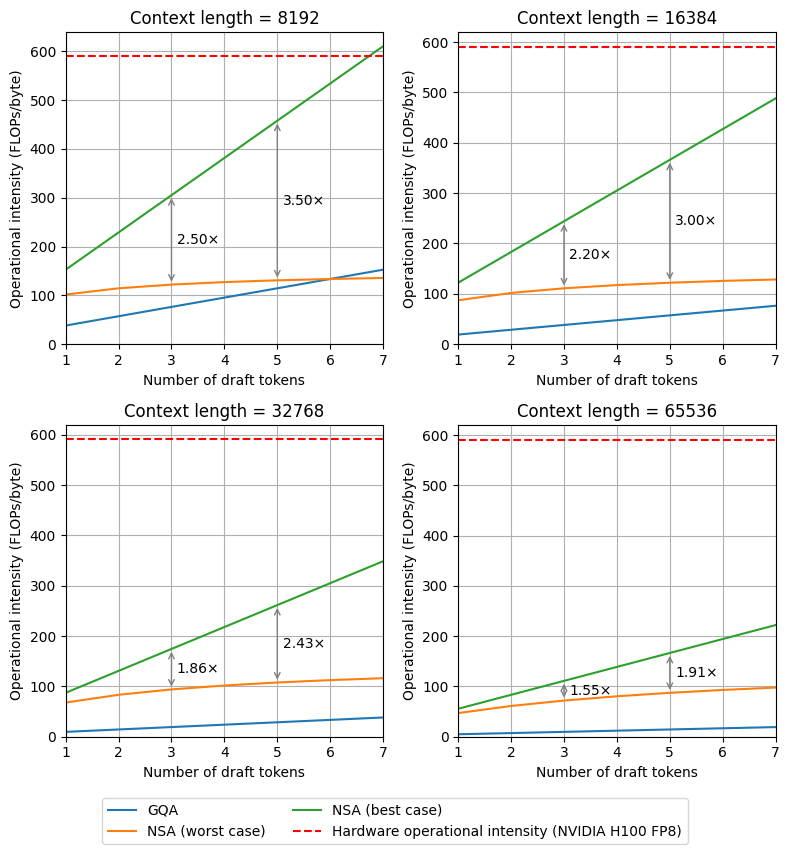

In [5]:
nsa_model = {"num_layers": 30, "n_kv": 4, "d_k": 192, "d_v": 128}
sizeof_kv = nsa_model["num_layers"] * nsa_model["n_kv"] * (nsa_model["d_k"] + nsa_model["d_v"])
N = 3e9  # 3B active parameters

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs = axs.flatten()

k = np.arange(1, 8)  # num_draft_tokens
for i, L in enumerate([8192, 16384, 32768, 65536]):
    B = 1  # infinite batch size limit
    FLOPs_verify = 2 * N * B * (k + 1)
    kv_verify_gqa = B * L * sizeof_kv

    num_compression_tokens = L // nsa_d
    num_selection_tokens_best_case = min(nsa_L * nsa_n, L)
    num_selection_tokens_worst_case = np.minimum(num_selection_tokens_best_case * (k + 1), L)
    num_window_tokens = min(nsa_w, L)

    num_nsa_tokens_worst_case = num_compression_tokens + num_selection_tokens_worst_case + num_window_tokens
    kv_verify_nsa_worst_case = B * num_nsa_tokens_worst_case * sizeof_kv

    num_nsa_tokens_best_case = num_compression_tokens + num_selection_tokens_best_case + num_window_tokens
    kv_verify_nsa_best_case = B * num_nsa_tokens_best_case * sizeof_kv

    OI_gqa = FLOPs_verify / kv_verify_gqa
    OI_nsa_worst_case = FLOPs_verify / kv_verify_nsa_worst_case
    OI_nsa_best_case = FLOPs_verify / kv_verify_nsa_best_case

    if plot_operational_intensity:
        axs[i].plot(k, OI_gqa, label="GQA")
        axs[i].plot(k, OI_nsa_worst_case, label="NSA (worst case)")
        axs[i].plot(k, OI_nsa_best_case, label="NSA (best case)")
        axs[i].axhline(591, color="red", linestyle="--", label="Hardware operational intensity (NVIDIA H100 FP8)")
    else:
        axs[i].plot(k, np.ones_like(k) * kv_verify_gqa, label="GQA")
        axs[i].plot(k, kv_verify_nsa_worst_case, label="NSA (worst case)")
        axs[i].plot(k, np.ones_like(k) * kv_verify_nsa_best_case, label="NSA (best case)")

    for num_draft_tokens in [3, 5]:  # for num_verified_tokens in [4, 6]
        idx = np.where(k == num_draft_tokens)[0][0]
        x_val = k[idx]
        y1 = OI_nsa_best_case[idx] if plot_operational_intensity else kv_verify_nsa_worst_case[idx]
        y2 = OI_nsa_worst_case[idx] if plot_operational_intensity else kv_verify_nsa_best_case
        ratio = y1 / y2
        axs[i].annotate(
            "",
            xy=(x_val, y2),
            xytext=(x_val, y1),
            arrowprops=dict(arrowstyle="<->", color="gray"),
            fontsize=10,
            ha='center'
        )
        axs[i].text(
            x_val + 0.1, (y1 + y2) / 2,
            f"{ratio:.2f}×",
            fontsize=10,
            va='center',
            ha='left'
        )

    axs[i].set_title(f"Context length = {L}")
    axs[i].set_xlabel("Number of draft tokens")
    axs[i].set_xlim(1, 7)
    axs[i].set_ylabel("Operational intensity (FLOPs/byte)" if plot_operational_intensity else "Memory access volume (bytes)")
    axs[i].set_ylim(0, None)
    axs[i].grid()

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.07))

plt.tight_layout()
plt.show()

# Figure 2

In [6]:
def plot_attn_mask(mask, ax=None, cbar_orientation=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_aspect("equal")
    cax = ax.imshow(mask, cmap="viridis", interpolation="nearest")
    if cbar_orientation:
        fig.colorbar(cax, ax=ax, orientation=cbar_orientation, pad=0.1)
    ax.set_xticks(np.arange(-0.5, mask.shape[1], 1))
    ax.set_yticks(np.arange(-0.5, mask.shape[0], 1))
    ax.grid(which="major", color="k", linestyle="-", linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", length=0)
    if ax is None:
        plt.show()

In [7]:
Klen = 128
nsa_l = 2  # compression block size
nsa_d = 1  # sliding stride
nsa_L = 4  # selected block size
nsa_n = 4  # selected block count
nsa_w = 8  # window size

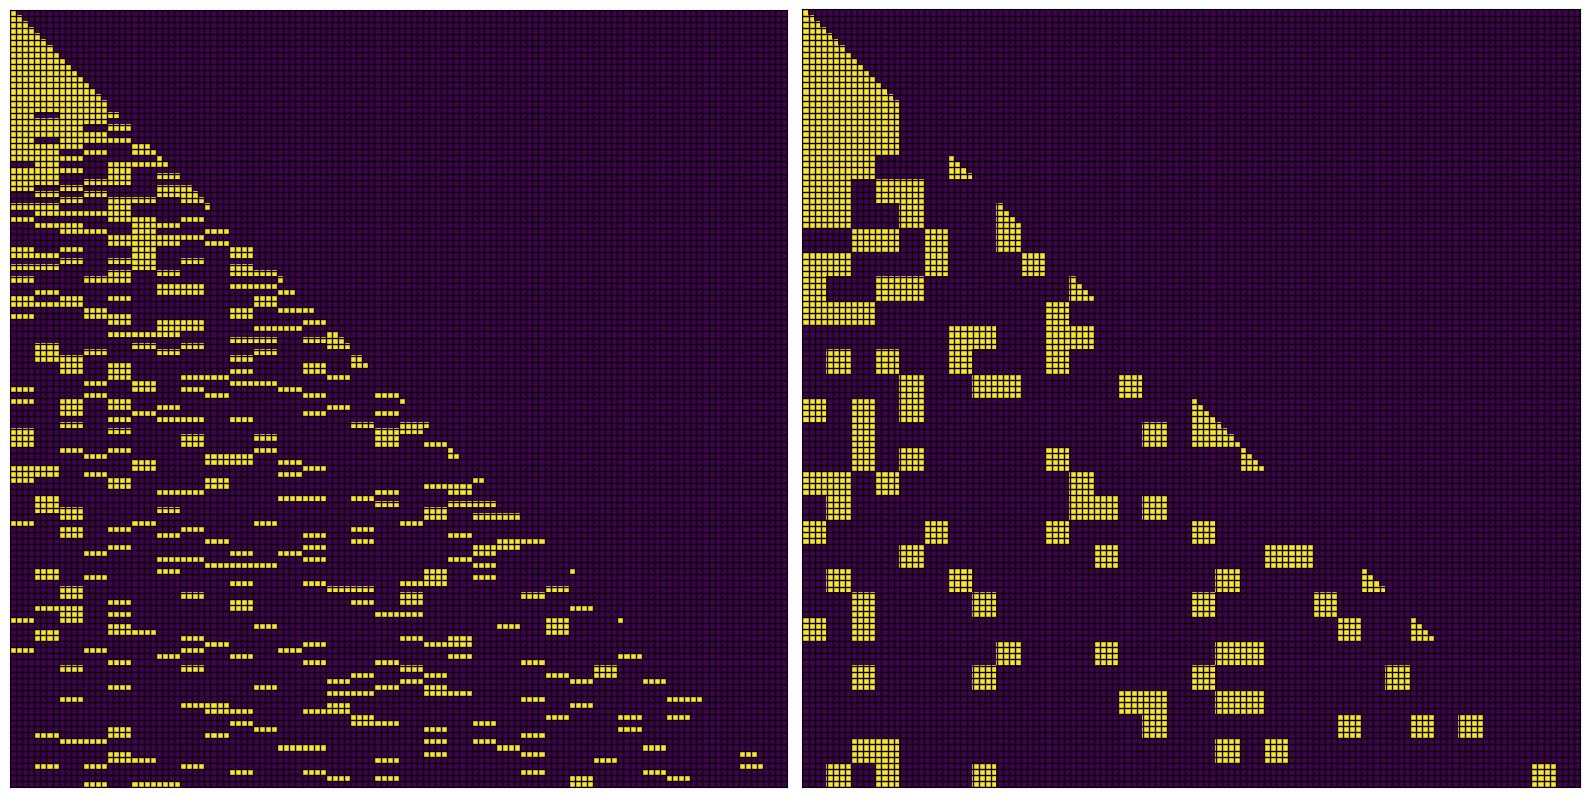

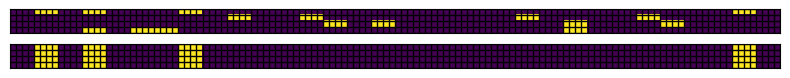

In [8]:
def get_dynamic_slc_mask(p_slc):
    block_indices_to_rank = [np.arange(0, 1 + t // nsa_L) for t in range(Klen)]
    ranked_slc_block_indices = [np.argsort(p_slc[t][block_indices_to_rank[t]])[::-1] for t in range(Klen)]
    dynamic_slc_block_indices = [(ranked_slc_block_indices[t])[: nsa_n] for t in range(Klen)]
    dynamic_slc_mask = np.zeros((Klen, Klen))
    for t in range(Klen):
        for i in dynamic_slc_block_indices[t]:
            dynamic_slc_mask[t, i * nsa_L : (i + 1) * nsa_L] = 1
    return dynamic_slc_mask


num_selected_blocks = Klen // nsa_L
np.random.seed(0)
p_slc = np.random.uniform(0, 1, (Klen, num_selected_blocks))
causal_mask = np.tril(np.ones((Klen, Klen)))
slc_mask = np.logical_and(causal_mask, get_dynamic_slc_mask(p_slc))

# Force each block of num_draft_tokens + 1 tokens to select the same KV.
num_draft_tokens = 3
p_slc = einops.rearrange(
    p_slc, "(n_qb K) n_sb -> n_qb K n_sb", K=num_draft_tokens + 1
)
p_slc = p_slc[..., 0, :]
p_slc = np.repeat(p_slc, num_draft_tokens + 1, axis=0)
modified_slc_mask = np.logical_and(causal_mask, get_dynamic_slc_mask(p_slc))

fig, axs = plt.subplots(1, 2, figsize=(16, 32))
plot_attn_mask(slc_mask, ax=axs[0])
plot_attn_mask(modified_slc_mask, ax=axs[1])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(8, 1))
plot_attn_mask(slc_mask[-(num_draft_tokens + 1):, :], ax=axs[0])
plot_attn_mask(modified_slc_mask[-(num_draft_tokens + 1):, :], ax=axs[1])
plt.tight_layout()
plt.show()

- In our experiments, we used the logic in the cell above to force a block of tokens to attend to the same subset of the context. This logic replaces $\mathbf{p}_{t + 1}^\text{slc}, \mathbf{p}_{t + 2}^\text{slc}, \dots, \mathbf{p}_{t + k}^\text{slc}$ with $\mathbf{p}_t^\text{slc}$, where $(\mathbf{p}_t^\text{slc})_i$ is the score given by token $t$ to block $i$. The scores $(\mathbf{p}_t^\text{slc})_i$ determine which attention scores must be computed.
    - Note that, for example, replacing $\mathbf{p}_{t}^\text{slc}, \mathbf{p}_{t + 1}^\text{slc}, \dots, \mathbf{p}_{t + k}^\text{slc}$ with $\text{mean}(\mathbf{p}_t^\text{slc}, \mathbf{p}_{t + 1}^\text{slc}, \dots, \mathbf{p}_{t + k}^\text{slc})$ breaks causality even if the selected attention mask is lower-triangular, since information from future tokens is used to determine which attention scores must be computed.
- The logic in the cell above is incorrect, however, if the number of draft tokens $k$ is greater or equal to the selected block size $\texttt{nsa\_L}$. The logic in the cell below is correct in all cases.

In [9]:
def get_dynamic_slc_mask_alt(p_slc, num_draft_tokens):
    block_indices_to_rank = [np.arange(0, 1 + t // nsa_L) for t in range(Klen)]
    ranked_slc_block_indices = [np.argsort(p_slc[t][block_indices_to_rank[t]])[::-1] for t in range(0, Klen, num_draft_tokens + 1)]
    dynamic_slc_block_indices = [(ranked_slc_block_indices[t])[: nsa_n] for t in range(Klen // (num_draft_tokens + 1))]
    dynamic_slc_mask = np.zeros((Klen, Klen))
    for t in range(0, Klen, num_draft_tokens + 1):
        for i in dynamic_slc_block_indices[t // (num_draft_tokens + 1)]:
            for j in range(num_draft_tokens + 1):
                dynamic_slc_mask[t + j, i * nsa_L : (i + 1) * nsa_L] = 1
    return dynamic_slc_mask

alternative_slc_mask = np.logical_and(causal_mask, get_dynamic_slc_mask_alt(p_slc, num_draft_tokens=num_draft_tokens))
assert np.all(alternative_slc_mask == modified_slc_mask)

## Table 2

In [10]:
df_2 = pd.DataFrame({
    "186M": {"NSA": "2.128", "$k=1$": "2.128", "$k=3$": "2.128", "$k=7$": "2.130"},
    "1177M": {"NSA": "1.794", "$k=1$": "1.794", "$k=3$": "1.793", "$k=7$": "1.794"},
}).T
df_2.index.name = "Parameters"
print(df_2.to_markdown())

| Parameters   |   NSA |   $k=1$ |   $k=3$ |   $k=7$ |
|:-------------|------:|--------:|--------:|--------:|
| 186M         | 2.128 |   2.128 |   2.128 |   2.13  |
| 1177M        | 1.794 |   1.794 |   1.793 |   1.794 |


## Table 3

In [11]:
df_3 = pd.DataFrame([
    {"Summary": "b)", "Description": "$n=4$ (no selection)", "NSA": "**2.147**", "$k=1$": "", "$k=3$": "", "$k=7$": ""},
    {"Summary": "", "Description": "Baseline ($n=4$)", "NSA": "**2.128**", "$k=1$": "**2.128**", "$k=3$": "**2.128**", "$k=7$": "2.130"},
    {"Summary": "a)", "Description": "Freely select $n=4$ blocks", "NSA": "2.132", "$k=1$": "2.129", "$k=3$": "**2.126**", "$k=7$": "2.127"},
    {"Summary": "c)", "Description": "$n=4$ at test-time", "NSA": "**2.128**", "$k=1$": "2.129", "$k=3$": "2.132", "$k=7$": "2.134"},
    {"Summary": "a), c)", "Description": "Freely select $n=4$ at test-time", "NSA": "**2.132**", "$k=1$": "**2.132**", "$k=3$": "2.133", "$k=7$": "2.135"},
])
df_3.index = range(1, len(df_3) + 1)
print(df_3.to_markdown())

|    | Summary   | Description                      | NSA       | $k=1$     | $k=3$     | $k=7$   |
|---:|:----------|:---------------------------------|:----------|:----------|:----------|:--------|
|  1 | b)        | $n=4$ (no selection)             | **2.147** |           |           |         |
|  2 |           | Baseline ($n=4$)                 | **2.128** | **2.128** | **2.128** | 2.130   |
|  3 | a)        | Freely select $n=4$ blocks       | 2.132     | 2.129     | **2.126** | 2.127   |
|  4 | c)        | $n=4$ at test-time               | **2.128** | 2.129     | 2.132     | 2.134   |
|  5 | a), c)    | Freely select $n=4$ at test-time | **2.132** | **2.132** | 2.133     | 2.135   |
